## Neural spike code

In this notebook an example of the library used on neural spike data is provided. We use synthetic data, generated from an Ising model with known couplings, so that the inferred couplings can be compared with the true ones. A neuron is +1 in a time bin if it spikes and −1 if it is silent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spininfer.models.ising import IsingModel
from spininfer.data.generate import generate_data
from spininfer.data.spikes import ising_dataset_from_spikes

N_TIMEBINS = 100_000
N_SWEEPS = 500
rng = np.random.default_rng(0)


def sparse_couplings(n, p_connect, scale, rng):
    """Symmetric random couplings where each pair is connected with probability p_connect."""
    connected = np.triu(rng.random((n, n)) < p_connect, k=1)
    J = np.triu(rng.normal(0.0, scale, (n, n)), k=1) * connected
    return J + J.T

In [2]:
N_NEURONS = 20
ising = IsingModel(n_sites=N_NEURONS, backend="numba")

# We use negative fields as we assume that neurons are mostly silent
h_true = -1.2 + rng.normal(0, 0.2, N_NEURONS)
J_true = sparse_couplings(N_NEURONS, p_connect=0.15, scale=0.5, rng=rng)

synth = generate_data(ising, n_samples=N_TIMEBINS, iterations=N_SWEEPS * N_NEURONS, seed=1, h=h_true, J=J_true)
samples = np.asarray(synth.samples)

# the fake recordings of the neurons
spike_times = [np.flatnonzero(samples[:, i] == 1) for i in range(N_NEURONS)]
print("firing probability per bin:", np.round([len(t) / N_TIMEBINS for t in spike_times], 3))
print(f"Number of neurons: {len(spike_times)}")

ising_dataset = ising_dataset_from_spikes(ising, spike_times, n_timepoints=N_TIMEBINS)


/scratch/scientific_env/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


firing probability per bin: [0.185 0.158 0.398 0.041 0.07  0.072 0.035 0.116 0.05  0.121 0.025 0.062
 0.04  0.059 0.072 0.107 0.044 0.054 0.097 0.132]
Number of neurons: 20


converged: True after 335 steps


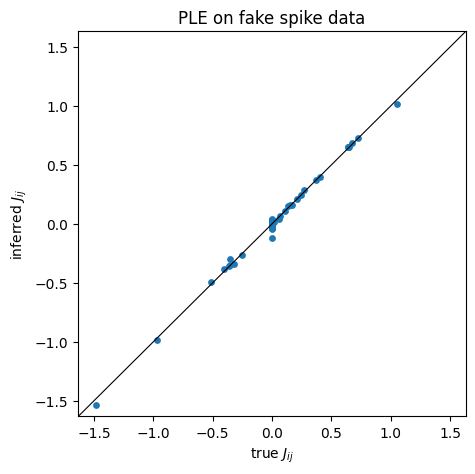

In [3]:
from spininfer.objectives.ple_ising import PleIsingObjective
from spininfer.fitters.lbfgs_fitter import LbfgsFitter

iu = np.triu_indices(N_NEURONS, k=1)

result = LbfgsFitter(model=ising, objective=PleIsingObjective(), dataset=ising_dataset).fit()
J_fit = np.asarray(result.J)
print(f"converged: {result.converged} after {result.n_steps} steps")

lim = 1.1 * np.max(np.abs(J_true))
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(J_true[iu], J_fit[iu], s=15)
ax.plot([-lim, lim], [-lim, lim], color="black", lw=0.8)
ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel=r"true $J_{ij}$", ylabel=r"inferred $J_{ij}$",
       title="PLE on fake spike data")
plt.show()


What can be seen is that in this regime, with plenty of time bins and not too skewed data, the couplings are almost perfectly recovered. 

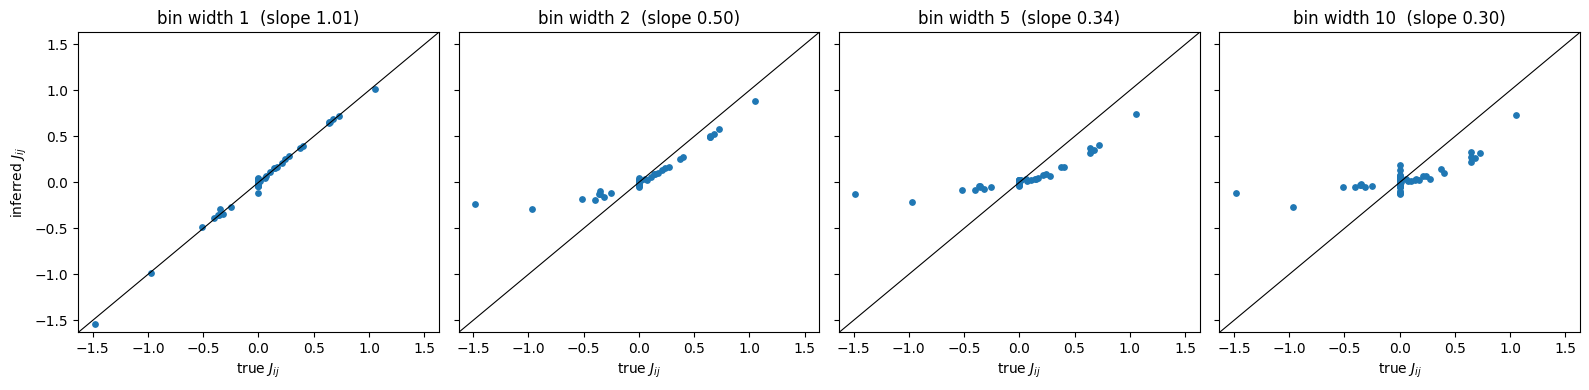

In [4]:
BIN_WIDTHS = [1, 2, 5, 10]
J_by_bin = {}

fig, axes = plt.subplots(1, len(BIN_WIDTHS), figsize=(4 * len(BIN_WIDTHS), 4), sharey=True)
for ax, bw in zip(axes, BIN_WIDTHS):
    dataset = ising_dataset_from_spikes(ising, spike_times, n_timepoints=N_TIMEBINS, bin_width=bw)
    J_bw = np.asarray(LbfgsFitter(model=ising, objective=PleIsingObjective(), dataset=dataset).fit().J)
    J_by_bin[bw] = J_bw 
    slope = np.polyfit(J_true[iu], J_bw[iu], 1)[0]

    ax.scatter(J_true[iu], J_bw[iu], s=15)
    ax.plot([-lim, lim], [-lim, lim], color="black", lw=0.8)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel=r"true $J_{ij}$",
           title=f"bin width {bw}  (slope {slope:.2f})")
axes[0].set_ylabel(r"inferred $J_{ij}$")
plt.tight_layout()
plt.show()


The results here show the inferred couplings at different bin widths. As expected, binning makes the recovery of the exact parameters worse. When binning, a neuron counts as spiking if it spikes anywhere in the window, so independent time bins are merged, the spike probability goes up and the correlations get washed out. There are also fewer samples left. In this synthetic data binning can only make things worse, since every time bin is independent. In real recordings this is different: neurons influence each other with a delay, and binning can also help when spikes are rare or when the spike timing is less certain than the time bin. Choosing the bin width is therefore a modelling choice.

Furthermore the negative (inhibitory) couplings shrink much more than the positive ones. With wide bins both neurons are likely to spike somewhere in the window anyway, so one neuron suppressing the other is lost, while neurons firing together is still visible.

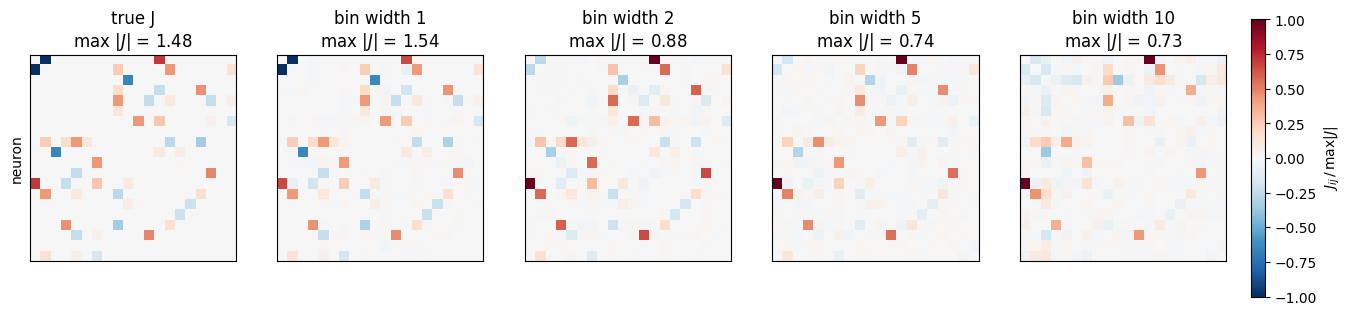

In [5]:
panels = [("true J", J_true)] + [(f"bin width {bw}", J_by_bin[bw]) for bw in BIN_WIDTHS]

fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 3.6))
for ax, (title, J) in zip(axes, panels):
    scale = np.max(np.abs(J))
    im = ax.imshow(J / scale, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set(title=f"{title}\nmax $|J|$ = {scale:.2f}", xticks=[], yticks=[])
axes[0].set_ylabel("neuron")
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label=r"$J_{ij}\,/\,\max|J|$")
plt.show()


While the previous code showed that the exact coupling recovery got worse, the code above shows that the strong couplings are still observed even while binning. The results only really get worse at a bin width of 10, where certain sites are saturated with +1 states.

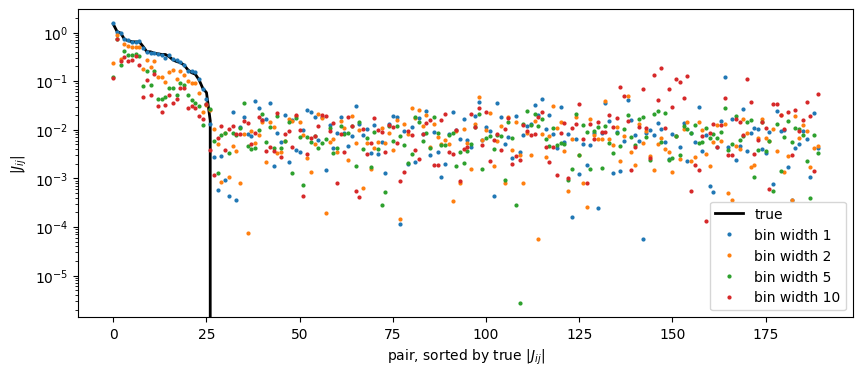

In [6]:
order = np.argsort(np.abs(J_true[iu]))[::-1]
rank = np.arange(len(order))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rank, np.abs(J_true[iu][order]), color="black", lw=2, label="true")
for bw in BIN_WIDTHS:
    ax.plot(rank, np.abs(J_by_bin[bw][iu][order]), ".", ms=4, label=f"bin width {bw}")
ax.set(xlabel="pair, sorted by true $|J_{ij}|$", ylabel=r"$|J_{ij}|$", yscale="log")
ax.legend()
plt.show()

In this plot the couplings are sorted by their true absolute strength, and for every bin width the inferred value of the same pair is plotted on top of each other. The pairs to the left of the drop are the true connections, the pairs to the right are not connected and should be zero. Without binning the inferred couplings follow the true couplings perfectly through to the weakest connect, while the unconnected pairs stay at a noise level of around $10^{-2}$. When the bin width increases the true couplings shrink towards this noise level. At bin width of 2 and 5 the significant and non-significant couplings can still be distinguished quite well, while for a bin width of 10 they are indistinguishable are some not real couplings also become strong.

